In [33]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Carregamento da Base de dados
Fonte: https://portal.inmet.gov.br/dadoshistoricos

In [34]:
# Arquivo de 2025 para base de aprendizado
df_treino = pd.read_csv("INMET_S_PR_A807_CURITIBA_01-01-2025_A_31-12-2025.CSV", # Lê o arquivo CSV
                        sep=';', # define o ponto e vírgula como separador de colunas
                        encoding='latin-1', # resolve problemas de acentuação comuns em arquivos brasileiros
                        skiprows=8, # pula as linhas iniciais do cabeçalho administrativo
                        decimal=',') # converte números como "15,5" para 15.5 (float)

# Arquivo de 2026 para validar o modelo depois
df_teste = pd.read_csv("INMET_S_PR_A807_CURITIBA_01-01-2026_A_28-02-2026.CSV", sep=';', encoding='latin-1', skiprows=8, decimal=',')

# Exibir colunas e primeiras linhas
display(df_treino.head())

,Data,Hora UTC,"PRECIPITAÇÃO TOTAL, HORÁRIO (mm)","PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)",PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB),PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB),RADIACAO GLOBAL (Kj/m²),"TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)",TEMPERATURA DO PONTO DE ORVALHO (°C),TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C),TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C),TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C),TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C),UMIDADE REL. MAX. NA HORA ANT. (AUT) (%),UMIDADE REL. MIN. NA HORA ANT. (AUT) (%),"UMIDADE RELATIVA DO AR, HORARIA (%)","VENTO, DIREÇÃO HORARIA (gr) (° (gr))","VENTO, RAJADA MAXIMA (m/s)","VENTO, VELOCIDADE HORARIA (m/s)",Unnamed: 19
0,2025/01/01,0000 UTC,0.0,911.1,911.1,910.2,NaN,20.3,18.3,20.4,20.2,18.6,18.1,90.0,88.0,89.0,77.0,5.2,2.0,NaN
1,2025/01/01,0100 UTC,0.0,911.7,911.8,911.1,NaN,20.0,18.1,20.4,20.0,18.6,17.9,89.0,88.0,89.0,84.0,5.5,3.0,NaN
2,2025/01/01,0200 UTC,0.0,911.4,911.7,911.3,NaN,19.7,18.1,20.0,19.6,18.3,18.0,91.0,89.0,90.0,92.0,6.0,2.4,NaN
3,2025/01/01,0300 UTC,0.0,911.3,911.4,911.2,NaN,19.7,18.0,19.8,19.7,18.2,17.9,91.0,90.0,90.0,78.0,5.8,2.7,NaN
4,2025/01/01,0400 UTC,0.0,911.0,911.3,911.0,NaN,19.4,18.0,19.7,19.4,18.1,17.9,92.0,90.0,92.0,77.0,6.3,2.3,NaN


Limpeza, organização e padronização dos dados
Definição das features e target

In [ ]:
# Substitui o valor de erro (-9999) por "NaN" nos dois DataFrames
df_treino = df_treino.replace(-9999, np.nan)
df_teste = df_teste.replace(-9999, np.nan)

#Separar apenas as colunas importantes para analisar a temperatura
col_umid = 'UMIDADE RELATIVA DO AR, HORARIA (%)'
col_pres = 'PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)'
col_rad  = 'RADIACAO GLOBAL (Kj/m²)'

features = [col_umid, col_pres, col_rad]

#Target - Variável alvo original
col_temp = 'TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)'

# Verificação de segurança
print(f"Total de registros para treino: {len(df_treino)}") #quantidade antes de limpar linhas vazias
print(f"Total de registros para teste: {len(df_teste)}")

Total de registros para treino: 8760
Total de registros para teste: 1416


In [ ]:
#Analise estatistica
estatisticas = df_treino[features + [col_temp]].describe()
print(estatisticas)

       UMIDADE RELATIVA DO AR, HORARIA (%)  \
count                          8256.000000   
mean                             80.241764   
std                              16.201403   
min                              17.000000   
25%                              70.000000   
50%                              86.000000   
75%                              93.000000   
max                             100.000000   

       PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)  \
count                                        8256.000000       
mean                                          913.660913       
std                                             4.026995       
min                                           897.100000       
25%                                           911.000000       
50%                                           913.500000       
75%                                           916.400000       
max                                           925.200000       

       R

Estatística Descritiva:

A análise de todos os registros mostra que Curitiba registrou uma média de 18,3°C. A menor temperatura foi -0,1°C e a maior 32,6°C. Isso mostra uma variação bem grande para o modelo aprender. A média da umidade relativa do ar foi de 80%, em alguns momentos a umidade caiu para 17%, mas na maior parte do tempo (75% dos dados) ela está acima de 70%.Radiação é a variável com maior variação (std de 1033) e Pressão Atmosférica é a variável mais estável, ficando quase sempre em torno de 913 mB.

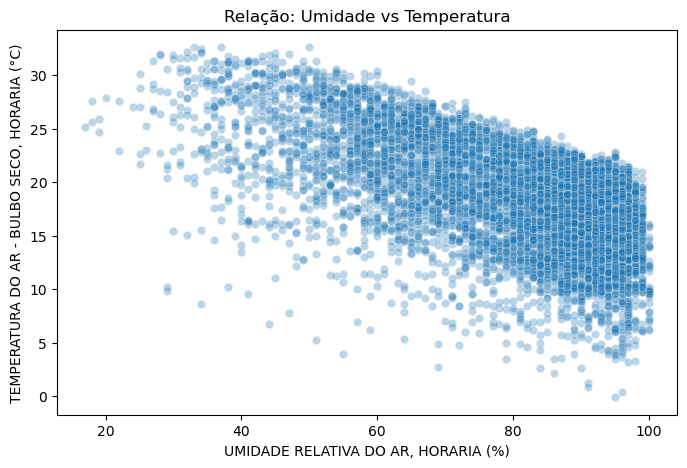

In [36]:
# Gráfico de Dispersão: Umidade vs Temperatura
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_treino, x='UMIDADE RELATIVA DO AR, HORARIA (%)', y=col_temp, alpha=0.3)
plt.title('Relação: Umidade vs Temperatura')
plt.show()

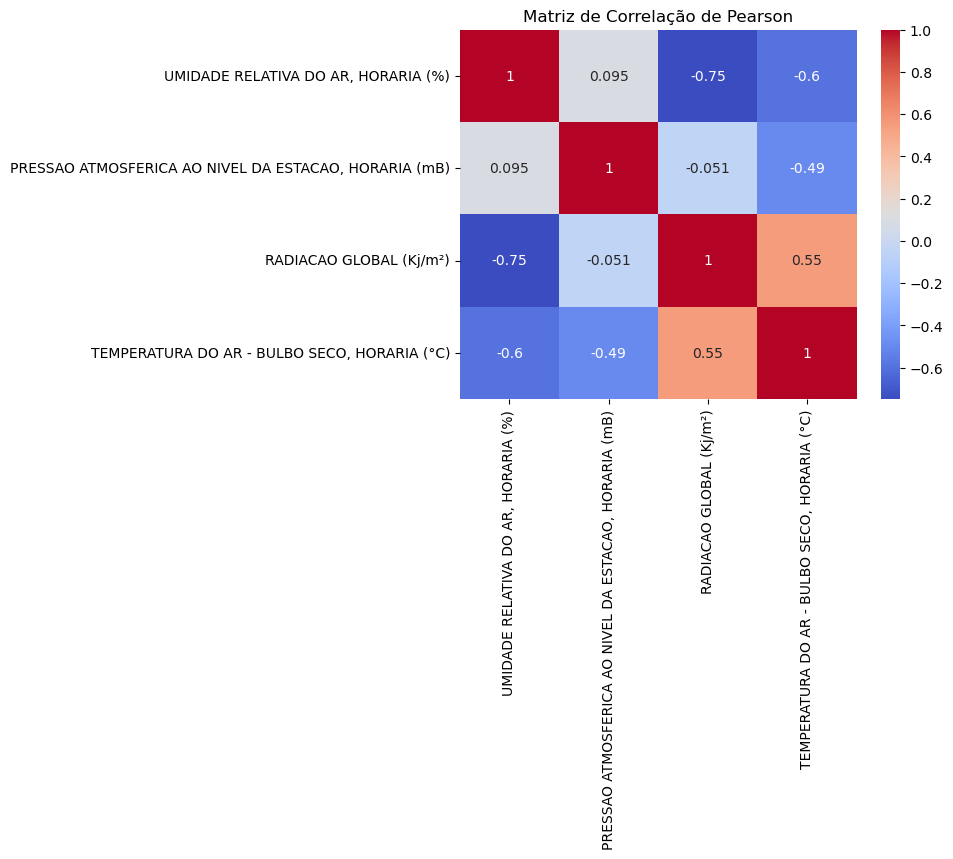

In [37]:
# Matriz de Correlação Numérica
corr = df_treino[features + [col_temp]].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Matriz de Correlação de Pearson')
plt.show()

O gráfico da Matriz de Correlação Numérica mostra as variáveis Radiação e Temperatura (0.55) têm uma correlação positiva, o que indica que se a Radiação sobe, a temperatura também sobe. Já as variáveis Umidade e Temperatura (-0.6) têm correlação negativa, o que indica que se a umidade sobe, a temperatura tende a cair. Radiação e Umidade é a relação mais forte do gráfico (-0.75) o que indica que dias com radiação maior, menor é a umidade.

In [ ]:
# Limpando linhas com valores nulos (NaN)
df_treino_reg = df_treino[features + [col_temp]].dropna()
df_teste_reg = df_teste[features + [col_temp]].dropna()

# Arquivo de Treino (2025)
X_train = df_treino_reg[features]
y_train = df_treino_reg[col_temp]

#Arquivo de teste (2026)
X_test = df_teste_reg[features]
y_test = df_teste_reg[col_temp]

# Padronização (Essencial para Regressão Linear e SVR)
scaler_reg = StandardScaler()
X_train_scaled = scaler_reg.fit_transform(X_train)
X_test_scaled = scaler_reg.transform(X_test)

print(f"Total de registros para treino: {len(X_train)}") #quantidade após limpar linhas vazias
print(f"Total de registros para teste: {len(X_test)}")

Total de registros para treino: 4930
Total de registros para teste: 936


Treinando os 4 Modelos de Regressão

In [39]:
# Regressão Linear
modelo_linear = LinearRegression()
modelo_linear.fit(X_train_scaled, y_train)

# Árvore de Decisão para Regressão
modelo_arvore_reg = DecisionTreeRegressor(max_depth=5, random_state=42)
modelo_arvore_reg.fit(X_train_scaled, y_train)

# Random Forest Regressor
modelo_rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_rf_reg.fit(X_train_scaled, y_train)

# SVR
modelo_svr = SVR(kernel='rbf')
modelo_svr.fit(X_train_scaled, y_train)

print('Modelos treinados')

Modelos treinados


In [ ]:
# Função para facilitar a coleta de métricas
def avaliar_regressao(modelo, X_teste, y_teste):
    preditos = modelo.predict(X_teste)
    mae = mean_absolute_error(y_teste, preditos)
    mse = mean_squared_error(y_teste, preditos)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_teste, preditos)
    return [mae, mse, rmse, r2]

# Coleta resultados de todos os modelos
resultados_reg = {
    'Regr. Linear': avaliar_regressao(modelo_linear, X_test_scaled, y_test),
    'Árvore': avaliar_regressao(modelo_arvore_reg, X_test_scaled, y_test),
    'Random Forest': avaliar_regressao(modelo_rf_reg, X_test_scaled, y_test),
    'SVR': avaliar_regressao(modelo_svr, X_test_scaled, y_test)
}

# Transforma em DataFrame
df_metricas = pd.DataFrame(resultados_reg, index=['MAE', 'MSE', 'RMSE', 'R2']).T
print(df_metricas)

                    MAE       MSE      RMSE        R2
Regr. Linear   2.016007  6.298955  2.509772  0.535977
Árvore         1.913347  5.686417  2.384621  0.581101
Random Forest  2.042325  6.544256  2.558174  0.517907
SVR            1.781701  4.929027  2.220141  0.636895


O modelo SVR se destacou como o mais preciso para a previsão de temperatura em Curitiba, apresentando um erro médio de apenas 1.78°C, superando a Regressão Linear e as árvores de decisão em todas as métricas de confiabilidade.

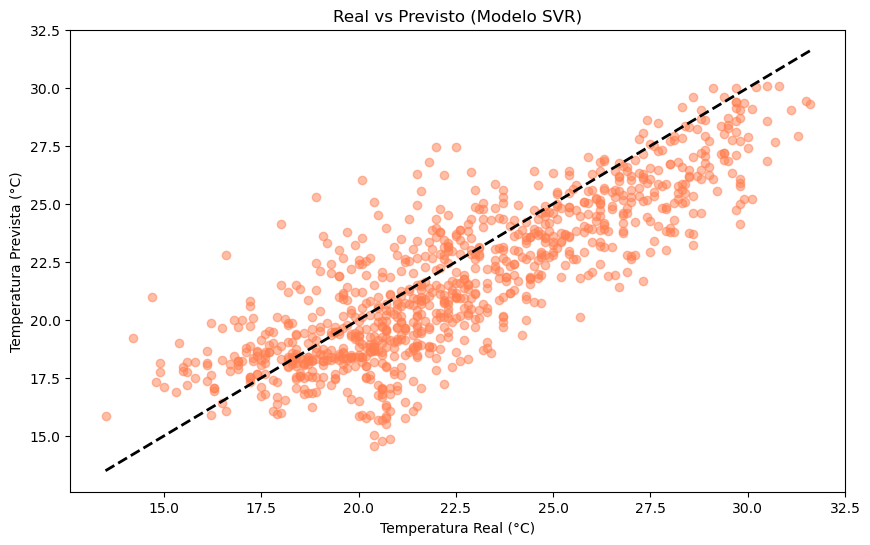

In [47]:
# Visualização: Real vs Previsto (Usando o Random Forest como exemplo)
previsoes_finais = modelo_svr.predict(X_test_scaled)
plt.figure(figsize=(10, 6))
plt.scatter(y_test, previsoes_finais, alpha=0.5, color='coral')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--k', lw=2)
plt.xlabel('Temperatura Real (°C)')
plt.ylabel('Temperatura Prevista (°C)')
plt.title('Real vs Previsto (Modelo SVR)')
plt.show()

In [49]:
def prever_temperatura():
    umid = float(input("Digite a Umidade (%): "))
    pres = float(input("Digite a Pressão (mB): "))
    radi = float(input("Digite a Radiação (Kj/m²): "))
    
    # Prepara os dados
    entrada = np.array([[umid, pres, radi]])
    entrada_scaled = scaler_reg.transform(entrada)
    
    # Previsão
    temp_prevista = modelo_rf_reg.predict(entrada_scaled)

    print("Umidade ", umid)
    print("Pressão  ", pres)
    print("Radiação  ", radi)
    
    print(f"\nPrevisão temperatura: {temp_prevista[0]:.1f}°C")

# Para testar:
prever_temperatura()

Umidade  95.0
Pressão   918.0
Radiação   100.0

Previsão temperatura: 14.3°C


c:\Users\desyr\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
